In [1]:
import numpy as np          # linear algebra
import pandas as pd         # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub


/kaggle/input/datasets/mohamadmahdimirzaie/top-eerste-voornamen-nl-2010-csv/Top_eerste_voornamen_NL_2010.csv


In [5]:
import os

# Automatically find the CSV file in the /kaggle/input/ folder
input_dir = '/kaggle/input'
csv_files = []
for dirname, _, filenames in os.walk(input_dir):
    for filename in filenames:
        if filename.endswith('.csv') and 'voornamen' in filename.lower():
            csv_files.append(os.path.join(dirname, filename))

if csv_files:
    file_path = csv_files[0]
    print(f"✅ Found file: {file_path}")
else:
    raise FileNotFoundError("No Dutch names CSV found in /kaggle/input/")

✅ Found file: /kaggle/input/datasets/mohamadmahdimirzaie/top-eerste-voornamen-nl-2010-csv/Top_eerste_voornamen_NL_2010.csv


In [2]:
import csv
import os

def find_csv_file():
    """Searches for the Dutch names CSV file in common locations."""
    search_dirs = [
        '/kaggle/input',
        '.',
        '../input',
    ]
    
    for search_dir in search_dirs:
        if not os.path.exists(search_dir):
            continue
        
        for dirpath, _, filenames in os.walk(search_dir):
            for filename in filenames:
                if filename.endswith('.csv') and 'voornamen' in filename.lower():
                    full_path = os.path.join(dirpath, filename)
                    print(f"✅ Found file: {full_path}")
                    return full_path
    
    return None

def extract_dutch_names(csv_file_path):
    """
    Reads a CSV file with multiple encoding fallbacks.
    """
    # List of possible encodings to try
    encodings = ['utf-8', 'latin-1', 'cp1252', 'iso-8859-1']
    
    for encoding in encodings:
        try:
            print(f"🔄 Trying encoding: {encoding}")
            with open(csv_file_path, 'r', encoding=encoding) as file:
                reader = csv.reader(file, delimiter=';')
                names = []
                
                for row in reader:
                    if len(row) < 2:
                        continue
                    
                    row = [field.strip() for field in row]
                    
                    if row[0].lower() in ['vrouwen', 'mannen', 'rank', '']:
                        continue
                    
                    name = row[1]
                    
                    if name and not name.isdigit() and len(name) > 1:
                        names.append(name)
                
                print(f"✅ Successfully read with encoding: {encoding}")
                return names
                
        except UnicodeDecodeError:
            print(f"❌ Failed with {encoding}, trying next...")
            continue
    
    raise UnicodeDecodeError("None of the attempted encodings worked for this file.")

def save_names_to_file(names, output_file='names.txt'):
    """Saves the list of names to a text file."""
    with open(output_file, 'w', encoding='utf-8') as f:
        for name in names:
            f.write(name + '\n')
    print(f"✅ Saved {len(names)} names to '{output_file}'")

# ------------------- MAIN EXECUTION -------------------
if __name__ == "__main__":
    # Step 1: Find the CSV file
    file_path = find_csv_file()
    
    if file_path is None:
        print("❌ Dutch names CSV file not found.")
        exit(1)
    
    # Step 2: Extract names with encoding fallback
    all_names = extract_dutch_names(file_path)
    
    # Step 3: Show preview
    print(f"\nTotal names extracted: {len(all_names)}")
    print("\nFirst 20 names:")
    for name in all_names[:20]:
        print(name)
    
    # Step 4: Save to names.txt
    save_names_to_file(all_names)

✅ Found file: /kaggle/input/datasets/mohamadmahdimirzaie/top-eerste-voornamen-nl-2010-csv/Top_eerste_voornamen_NL_2010.csv
🔄 Trying encoding: utf-8
❌ Failed with utf-8, trying next...
🔄 Trying encoding: latin-1
✅ Successfully read with encoding: latin-1

Total names extracted: 1490

First 20 names:
Maria
Johanna
Anna
Cornelia
Elisabeth
Wilhelmina
Catharina
Hendrika
Adriana
Petronella
Margaretha
Jacoba
Yvonne
Helena
Geertruida
Monique
Antonia
Esther
Ingrid
Christina
✅ Saved 1490 names to 'names.txt'


In [3]:
import torch
import pickle
import pandas as pd
from tabulate import tabulate

# ------------------- STEP 1: READ DATA -------------------
with open('names.txt', 'r', encoding='utf-8') as f:
    words = [line.strip() for line in f if line.strip()]

# ------------------- STEP 2: BUILD VOCABULARY -------------------
chars = sorted(list(set(''.join(words))))
chars.append('.')  # special token for start/end

stoi = {s: i for i, s in enumerate(chars)}
itos = {i: s for s, i in stoi.items()}
vocab_size = len(chars)

# ------------------- STEP 3: DISPLAY SUMMARY TABLE -------------------
data = {
    "Description": [
        "Total names loaded",
        "Unique characters (without '.')",
        "Vocabulary size (with '.')",
        "Sample names (first 5)",
        "First 5 chars (sorted)",
        "stoi mapping (first 5)",
        "itos mapping (first 5)"
    ],
    "Value": [
        len(words),
        len(chars) - 1,
        vocab_size,
        str(words[:5]),
        str(chars[:5]),
        str({k: stoi[k] for k in list(stoi.keys())[:5]}),
        str({k: itos[k] for k in list(itos.keys())[:5]})
    ]
}

df = pd.DataFrame(data)
print("\n📊 VOCABULARY SUMMARY TABLE")
print(tabulate(df, headers='keys', tablefmt='fancy_grid', showindex=False))

# ------------------- STEP 4: SAVE RESULTS TO FILES -------------------
# 4.1 Save summary as text file
with open('vocabulary_summary.txt', 'w', encoding='utf-8') as f:
    f.write("VOCABULARY SUMMARY\n")
    f.write("=" * 50 + "\n")
    f.write(f"Total names loaded     : {len(words)}\n")
    f.write(f"Unique characters      : {len(chars)-1}\n")
    f.write(f"Vocabulary size        : {vocab_size}\n")
    f.write(f"Sample names           : {words[:5]}\n")
    f.write(f"All characters         : {chars}\n")
    f.write(f"stoi (first 10)        : { {k: stoi[k] for k in list(stoi.keys())[:10]} }\n")
    f.write(f"itos (first 10)        : { {k: itos[k] for k in list(itos.keys())[:10]} }\n")

# 4.2 Save vocabulary dictionaries using pickle
with open('stoi.pkl', 'wb') as f:
    pickle.dump(stoi, f)

with open('itos.pkl', 'wb') as f:
    pickle.dump(itos, f)

# 4.3 Save the list of words (optional)
with open('words.pkl', 'wb') as f:
    pickle.dump(words, f)

print("\n💾 Files saved successfully:")
print("   - vocabulary_summary.txt")
print("   - stoi.pkl")
print("   - itos.pkl")
print("   - words.pkl")

# ------------------- STEP 5: SHOW SAMPLE MAPPINGS -------------------
print("\n🔍 Sample mappings (stoi):")
for ch in list(stoi.keys())[:10]:
    print(f"   '{ch}' → {stoi[ch]}")

print("\n🔍 Sample mappings (itos):")
for idx in list(itos.keys())[:10]:
    print(f"   {idx} → '{itos[idx]}'")


📊 VOCABULARY SUMMARY TABLE
╒═════════════════════════════════╤═══════════════════════════════════════════════════════╕
│ Description                     │ Value                                                 │
╞═════════════════════════════════╪═══════════════════════════════════════════════════════╡
│ Total names loaded              │ 1490                                                  │
├─────────────────────────────────┼───────────────────────────────────────────────────────┤
│ Unique characters (without '.') │ 60                                                    │
├─────────────────────────────────┼───────────────────────────────────────────────────────┤
│ Vocabulary size (with '.')      │ 61                                                    │
├─────────────────────────────────┼───────────────────────────────────────────────────────┤
│ Sample names (first 5)          │ ['Maria', 'Johanna', 'Anna', 'Cornelia', 'Elisabeth'] │
├─────────────────────────────────┼─────────────────

✅ Loaded vocabulary with 61 characters.
✅ Total bigrams counted: 10891

📊 BIGRAM STATISTICS SUMMARY
╒═════════════════════════════════╤══════════╕
│ Metric                          │ Value    │
╞═════════════════════════════════╪══════════╡
│ Vocabulary size (including '.') │ 61       │
├─────────────────────────────────┼──────────┤
│ Total names                     │ 1490     │
├─────────────────────────────────┼──────────┤
│ Total bigrams counted           │ 10891    │
├─────────────────────────────────┼──────────┤
│ Unique bigrams observed         │ 605      │
├─────────────────────────────────┼──────────┤
│ Max count for a single bigram   │ 582      │
├─────────────────────────────────┼──────────┤
│ Min count (non-zero)            │ 1        │
├─────────────────────────────────┼──────────┤
│ Most common bigram              │ a. (582) │
├─────────────────────────────────┼──────────┤
│ Least common bigram (non-zero)  │ .Ö (1)   │
╘═════════════════════════════════╧══════════╛

🏆 TOP 

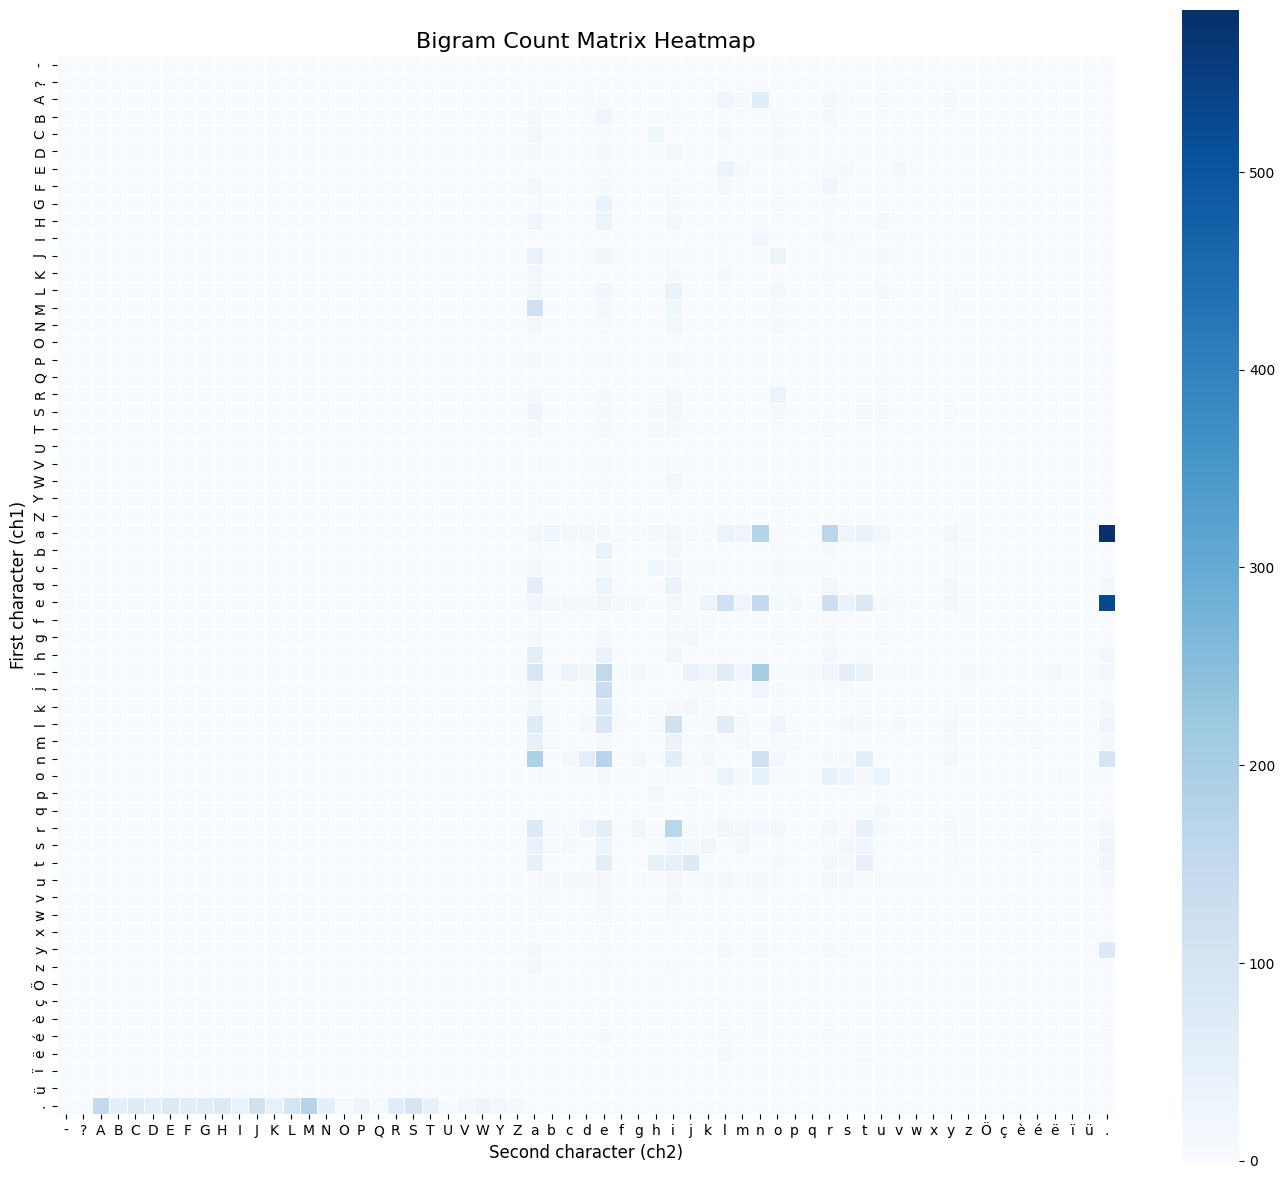

In [4]:
import torch
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

# ------------------- LOAD PREVIOUS RESULTS -------------------
with open('stoi.pkl', 'rb') as f:
    stoi = pickle.load(f)

with open('itos.pkl', 'rb') as f:
    itos = pickle.load(f)

with open('words.pkl', 'rb') as f:
    words = pickle.load(f)

vocab_size = len(stoi)
print(f"✅ Loaded vocabulary with {vocab_size} characters.")

# ------------------- STEP 1: COUNT BIGRAMS -------------------
# Initialize count matrix (vocab_size × vocab_size)
N = torch.zeros((vocab_size, vocab_size), dtype=torch.int32)

# Count bigrams
for w in words:
    chs = ['.'] + list(w) + ['.']   # start and end with '.'
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

total_bigrams = N.sum().item()
print(f"✅ Total bigrams counted: {total_bigrams}")

# ------------------- STEP 2: FIND TOP BIGRAMS -------------------
# Flatten the matrix and sort to find top bigrams
bigram_list = []
for i in range(vocab_size):
    for j in range(vocab_size):
        count = N[i, j].item()
        if count > 0:
            bigram_list.append({
                'ch1': itos[i],
                'ch2': itos[j],
                'count': count
            })

# Sort by count descending
bigram_list_sorted = sorted(bigram_list, key=lambda x: x['count'], reverse=True)

# ------------------- STEP 3: DISPLAY STATISTICS TABLE -------------------
stats_data = {
    "Metric": [
        "Vocabulary size (including '.')",
        "Total names",
        "Total bigrams counted",
        "Unique bigrams observed",
        "Max count for a single bigram",
        "Min count (non-zero)",
        "Most common bigram",
        "Least common bigram (non-zero)"
    ],
    "Value": [
        vocab_size,
        len(words),
        total_bigrams,
        len(bigram_list),
        bigram_list_sorted[0]['count'],
        bigram_list_sorted[-1]['count'],
        f"{bigram_list_sorted[0]['ch1']}{bigram_list_sorted[0]['ch2']} ({bigram_list_sorted[0]['count']})",
        f"{bigram_list_sorted[-1]['ch1']}{bigram_list_sorted[-1]['ch2']} ({bigram_list_sorted[-1]['count']})"
    ]
}

df_stats = pd.DataFrame(stats_data)
print("\n📊 BIGRAM STATISTICS SUMMARY")
print(tabulate(df_stats, headers='keys', tablefmt='fancy_grid', showindex=False))

# ------------------- STEP 4: DISPLAY TOP 15 BIGRAMS TABLE -------------------
top_15 = bigram_list_sorted[:15]
df_top = pd.DataFrame(top_15)
print("\n🏆 TOP 15 MOST FREQUENT BIGRAMS")
print(tabulate(df_top, headers='keys', tablefmt='fancy_grid', showindex=False))

# ------------------- STEP 5: SAVE RESULTS -------------------
# Save count matrix
torch.save(N, 'N_counts.pt')

# Save bigram list as CSV
df_all = pd.DataFrame(bigram_list)
df_all.to_csv('bigram_counts.csv', index=False)

# Save summary stats as text
with open('bigram_summary.txt', 'w', encoding='utf-8') as f:
    f.write("BIGRAM COUNTING SUMMARY\n")
    f.write("=" * 50 + "\n")
    f.write(f"Vocabulary size      : {vocab_size}\n")
    f.write(f"Total names          : {len(words)}\n")
    f.write(f"Total bigrams        : {total_bigrams}\n")
    f.write(f"Unique bigrams       : {len(bigram_list)}\n")
    f.write(f"Most common bigram   : {bigram_list_sorted[0]['ch1']}{bigram_list_sorted[0]['ch2']} ({bigram_list_sorted[0]['count']})\n")
    f.write(f"Least common bigram  : {bigram_list_sorted[-1]['ch1']}{bigram_list_sorted[-1]['ch2']} ({bigram_list_sorted[-1]['count']})\n")

print("\n💾 Files saved:")
print("   - N_counts.pt      (count matrix)")
print("   - bigram_counts.csv (all bigrams with counts)")
print("   - bigram_summary.txt (summary statistics)")

# ------------------- STEP 6: VISUALIZE HEATMAP (optional) -------------------
plt.figure(figsize=(14, 12))
sns.heatmap(N.numpy(), 
            xticklabels=[itos[i] for i in range(vocab_size)],
            yticklabels=[itos[i] for i in range(vocab_size)],
            cmap='Blues', 
            cbar=True,
            square=True,
            linewidths=0.5,
            annot=False)  # set annot=True for numbers (may be crowded)
plt.title('Bigram Count Matrix Heatmap', fontsize=16)
plt.xlabel('Second character (ch2)', fontsize=12)
plt.ylabel('First character (ch1)', fontsize=12)
plt.tight_layout()
plt.savefig('bigram_heatmap.png', dpi=150)
print("   - bigram_heatmap.png (heatmap image)")
plt.show()

In [5]:
import torch
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
import numpy as np

# ------------------- LOAD PREVIOUS RESULTS -------------------
with open('stoi.pkl', 'rb') as f:
    stoi = pickle.load(f)

with open('itos.pkl', 'rb') as f:
    itos = pickle.load(f)

# Load the count matrix
N = torch.load('N_counts.pt')
vocab_size = len(stoi)

print(f"✅ Loaded count matrix N with shape {N.shape}")
print(f"   Total bigrams: {N.sum().item()}")

# ------------------- STEP 1: CONVERT TO PROBABILITY MATRIX -------------------
# Convert to float
N_float = N.float()

# Calculate row sums (keep dimensions for broadcasting)
row_sums = N_float.sum(dim=1, keepdim=True)

# Handle zero-sum rows (safety, though all should have counts)
# If a row sums to 0, we set it to uniform distribution (optional)
# Let's check if any row sum is 0
if (row_sums == 0).any():
    print("⚠️  Warning: Some rows have zero sum. Applying Laplace smoothing.")
    # Add Laplace smoothing (add 1 to each count)
    P = (N_float + 1) / (row_sums + vocab_size)
else:
    # Normalize each row to sum to 1
    P = N_float / row_sums

print("✅ Converted N to probability matrix P")
print(f"   Row sums (first 5): {P.sum(dim=1)[:5].tolist()}")

# ------------------- STEP 2: DISPLAY STATISTICS TABLE -------------------
stats_data = {
    "Metric": [
        "Matrix shape",
        "Total probability mass (sum of all P)",
        "Max probability in P",
        "Min probability in P (non-zero)",
        "Average row entropy (predictability)",
        "Character with max start probability (P['.'][:])",
        "Character with max end probability (P[:]['.'])"
    ],
    "Value": [
        f"{P.shape[0]} × {P.shape[1]}",
        f"{P.sum().item():.4f} (should equal {vocab_size})",
        f"{P.max().item():.4f}",
        f"{P[P > 0].min().item():.4f}",
        f"{- (P * torch.log(P + 1e-10)).sum(dim=1).mean().item():.4f}",
        f"{itos[P[stoi['.']].argmax().item()]} ({P[stoi['.']].max().item():.4f})",
        f"{itos[P[:, stoi['.']].argmax().item()]} ({P[:, stoi['.']].max().item():.4f})"
    ]
}

df_stats = pd.DataFrame(stats_data)
print("\n📊 PROBABILITY MATRIX STATISTICS")
print(tabulate(df_stats, headers='keys', tablefmt='fancy_grid', showindex=False))

# ------------------- STEP 3: DISPLAY CONDITIONAL PROBABILITIES FOR KEY CHARACTERS -------------------
# Show top 5 most likely next characters for specific starting characters
chars_to_inspect = ['.', 'a', 'e', 'n', 'i']  # start, common letters

prob_data = []
for ch in chars_to_inspect:
    ix = stoi[ch]
    probs = P[ix]
    
    # Get top 5 next characters
    top_indices = probs.topk(5).indices.tolist()
    top_chars = [itos[idx] for idx in top_indices]
    top_probs = [probs[idx].item() for idx in top_indices]
    
    row = {
        'Current char': f"'{ch}'",
        'Most likely next': f"'{top_chars[0]}' ({top_probs[0]:.3f})",
        '2nd': f"'{top_chars[1]}' ({top_probs[1]:.3f})",
        '3rd': f"'{top_chars[2]}' ({top_probs[2]:.3f})",
        '4th': f"'{top_chars[3]}' ({top_probs[3]:.3f})",
        '5th': f"'{top_chars[4]}' ({top_probs[4]:.3f})"
    }
    prob_data.append(row)

df_probs = pd.DataFrame(prob_data)
print("\n🔍 CONDITIONAL PROBABILITY (Top 5 next chars given current char)")
print(tabulate(df_probs, headers='keys', tablefmt='fancy_grid', showindex=False))

# ------------------- STEP 4: SAVE RESULTS -------------------
# Save probability matrix
torch.save(P, 'P_probs.pt')

# Save summary as text
with open('probability_summary.txt', 'w', encoding='utf-8') as f:
    f.write("PROBABILITY MATRIX SUMMARY\n")
    f.write("=" * 50 + "\n")
    f.write(f"Matrix shape         : {P.shape[0]} x {P.shape[1]}\n")
    f.write(f"Total sum            : {P.sum().item():.4f}\n")
    f.write(f"Max probability      : {P.max().item():.4f}\n")
    f.write(f"Min (non-zero)       : {P[P > 0].min().item():.4f}\n")
    f.write(f"Avg row entropy      : {- (P * torch.log(P + 1e-10)).sum(dim=1).mean().item():.4f}\n")
    f.write("\nTop 10 most predictable rows (lowest entropy):\n")
    
    # Compute row entropy
    row_entropy = -(P * torch.log(P + 1e-10)).sum(dim=1)
    top_predictable = row_entropy.argsort()[:5]
    for idx in top_predictable:
        f.write(f"  '{itos[idx]}' : entropy = {row_entropy[idx].item():.4f}\n")

print("\n💾 Files saved:")
print("   - P_probs.pt (probability matrix)")
print("   - probability_summary.txt (stats)")

# ------------------- STEP 5: VISUALIZE PROBABILITY HEATMAP -------------------
plt.figure(figsize=(14, 12))
sns.heatmap(P.numpy(), 
            xticklabels=[itos[i] for i in range(vocab_size)],
            yticklabels=[itos[i] for i in range(vocab_size)],
            cmap='Blues', 
            cbar=True,
            square=True,
            linewidths=0.5,
            annot=False,
            vmin=0, vmax=0.4)  # Focus on lower probabilities for better contrast

plt.title('Bigram Probability Matrix Heatmap (Row-normalized)', fontsize=16)
plt.xlabel('Second character (ch2)', fontsize=12)
plt.ylabel('First character (ch1)', fontsize=12)
plt.tight_layout()
plt.savefig('probability_heatmap.png', dpi=150)
print("   - probability_heatmap.png (heatmap image)")
plt.show()

# ------------------- BONUS: SHOW START DISTRIBUTION -------------------
print("\n📈 DISTRIBUTION OF FIRST LETTERS (P['.'][:])")
start_probs = P[stoi['.']]
top_starts = start_probs.topk(10)
start_chars = [itos[i] for i in top_starts.indices.tolist()]
start_values = top_starts.values.tolist()

# Bar chart for first letters
plt.figure(figsize=(12, 6))
plt.bar(start_chars, start_values, color='skyblue', edgecolor='black')
plt.title('Top 10 Most Common Starting Letters (after ".")', fontsize=14)
plt.xlabel('Starting Letter', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.ylim(0, 0.25)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(start_values):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('start_letter_distribution.png', dpi=150)
print("   - start_letter_distribution.png (bar chart)")
plt.show()

✅ Loaded count matrix N with shape torch.Size([61, 61])
   Total bigrams: 10891
✅ Converted N to probability matrix P
   Row sums (first 5): [1.0, 1.0, 1.0000001192092896, 1.0, 1.0000001192092896]

📊 PROBABILITY MATRIX STATISTICS
╒══════════════════════════════════════════════════╤═══════════════════════════╕
│ Metric                                           │ Value                     │
╞══════════════════════════════════════════════════╪═══════════════════════════╡
│ Matrix shape                                     │ 61 × 61                   │
├──────────────────────────────────────────────────┼───────────────────────────┤
│ Total probability mass (sum of all P)            │ 61.0000 (should equal 61) │
├──────────────────────────────────────────────────┼───────────────────────────┤
│ Max probability in P                             │ 1.0000                    │
├──────────────────────────────────────────────────┼───────────────────────────┤
│ Min probability in P (non-zero)        

KeyError: tensor(43)

In [7]:
# ------------------- SAVE RESULTS (COMPLETE) -------------------
torch.save(P, 'P_probs.pt')

with open('probability_summary.txt', 'w', encoding='utf-8') as f:
    f.write("PROBABILITY MATRIX SUMMARY\n")
    f.write("=" * 50 + "\n")
    f.write(f"Matrix shape         : {P.shape[0]} x {P.shape[1]}\n")
    f.write(f"Total sum            : {P.sum().item():.4f}\n")
    f.write(f"Max probability      : {P.max().item():.4f}\n")
    f.write(f"Min (non-zero)       : {P[P > 0].min().item():.4f}\n")
    f.write(f"Avg row entropy      : {(- (P * torch.log(P + 1e-10)).sum(dim=1).mean().item()):.4f}\n")
    f.write("\nTop 10 most predictable rows (lowest entropy):\n")
    
    row_entropy = -(P * torch.log(P + 1e-10)).sum(dim=1)
    top_predictable = row_entropy.argsort()[:10]
    
    for idx in top_predictable:
        idx_int = idx.item()
        f.write(f"  '{itos[idx_int]}' : entropy = {row_entropy[idx_int].item():.4f}\n")

print("\n✅ Files saved successfully:")
print("   - P_probs.pt")
print("   - probability_summary.txt")


✅ Files saved successfully:
   - P_probs.pt
   - probability_summary.txt


✅ Probability matrix shape: torch.Size([61, 61])
✅ Row 0 sum: 1.0000
💾 Saved P_probs.pt

🔍 SAMPLE BIGRAM PROBABILITIES (from P matrix)
╒══════════╤══════════╤═══════════════╕
│ Name     │ Bigram   │   Probability │
╞══════════╪══════════╪═══════════════╡
│ Maria    │ .M       │        0.1181 │
├──────────┼──────────┼───────────────┤
│ Maria    │ Ma       │        0.6893 │
├──────────┼──────────┼───────────────┤
│ Maria    │ ar       │        0.1383 │
├──────────┼──────────┼───────────────┤
│ Maria    │ ri       │        0.2943 │
├──────────┼──────────┼───────────────┤
│ Maria    │ ia       │        0.1041 │
├──────────┼──────────┼───────────────┤
│ Maria    │ a.       │        0.4736 │
├──────────┼──────────┼───────────────┤
│ Johanna  │ .J       │        0.0785 │
├──────────┼──────────┼───────────────┤
│ Johanna  │ Jo       │        0.2917 │
├──────────┼──────────┼───────────────┤
│ Johanna  │ oh       │        0.0105 │
├──────────┼──────────┼───────────────┤
│ Johanna  │ ha       │  

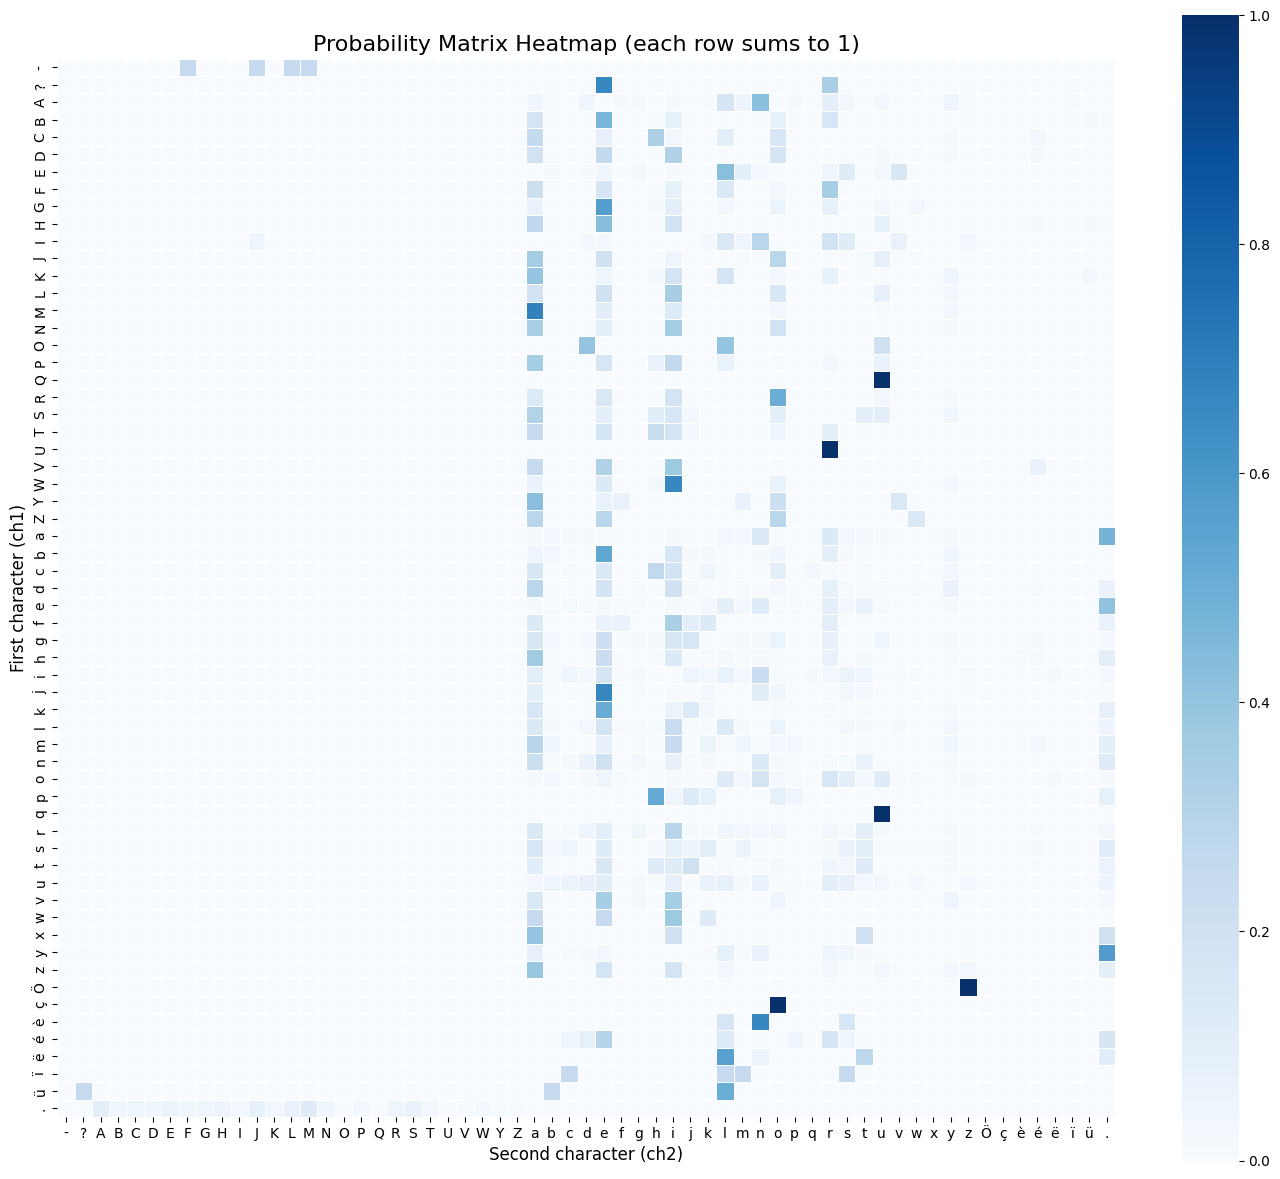

💾 Saved probability_heatmap.png


In [9]:
import torch
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

# ------------------- LOAD PREVIOUS DATA -------------------
with open('stoi.pkl', 'rb') as f:
    stoi = pickle.load(f)

with open('itos.pkl', 'rb') as f:
    itos = pickle.load(f)

# Load count matrix
N = torch.load('N_counts.pt')
vocab_size = len(stoi)

# ------------------- STEP 1: CONVERT TO PROBABILITY MATRIX -------------------
# Use broadcasting to normalize each row
P = N.float()
P = P / P.sum(dim=1, keepdim=True)   # each row sums to 1

print(f"✅ Probability matrix shape: {P.shape}")
print(f"✅ Row 0 sum: {P[0].sum().item():.4f}")  # should be 1.0

# ------------------- STEP 2: SAVE PROBABILITY MATRIX -------------------
torch.save(P, 'P_probs.pt')
print("💾 Saved P_probs.pt")

# ------------------- STEP 3: DISPLAY SAMPLE BIGRAMS WITH PROBABILITIES -------------------
# Choose a few Dutch names to show their bigram probabilities
sample_names = ['Maria', 'Johanna', 'Anna', 'Cornelia']

rows = []
for name in sample_names:
    chs = ['.'] + list(name) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2].item()
        rows.append({
            'Name': name,
            'Bigram': f'{ch1}{ch2}',
            'Probability': f'{prob:.4f}'
        })

df_sample = pd.DataFrame(rows)
print("\n🔍 SAMPLE BIGRAM PROBABILITIES (from P matrix)")
print(tabulate(df_sample, headers='keys', tablefmt='fancy_grid', showindex=False))

# ------------------- STEP 4: DISPLAY TOP 10 PROBABILITIES PER ROW -------------------
# For example, show top 3 most probable next characters for each of the first 5 characters
print("\n🏆 TOP 3 MOST PROBABLE NEXT CHARACTERS FOR EACH STARTING CHARACTER")
for ch in ['.', 'M', 'A', 'J', 'C']:
    ix = stoi[ch]
    probs = P[ix]
    # Get indices of top 3 probabilities
    top_vals, top_idxs = torch.topk(probs, k=3)
    top_chars = [itos[idx.item()] for idx in top_idxs]
    top_probs = [f'{v.item():.3f}' for v in top_vals]
    print(f"  {ch}: {list(zip(top_chars, top_probs))}")

# ------------------- STEP 5: HEATMAP OF PROBABILITY MATRIX -------------------
plt.figure(figsize=(14, 12))
sns.heatmap(P.numpy(),
            xticklabels=[itos[i] for i in range(vocab_size)],
            yticklabels=[itos[i] for i in range(vocab_size)],
            cmap='Blues',
            cbar=True,
            square=True,
            linewidths=0.5,
            annot=False)
plt.title('Probability Matrix Heatmap (each row sums to 1)', fontsize=16)
plt.xlabel('Second character (ch2)', fontsize=12)
plt.ylabel('First character (ch1)', fontsize=12)
plt.tight_layout()
plt.savefig('probability_heatmap.png', dpi=150)
plt.show()
print("💾 Saved probability_heatmap.png")

# ------------------- STEP 6: SAVE SUMMARY STATS -------------------
with open('probability_summary.txt', 'w', encoding='utf-8') as f:
    f.write("PROBABILITY MATRIX SUMMARY\n")
    f.write("=" * 50 + "\n")
    f.write(f"Matrix shape: {P.shape}\n")
    f.write(f"Row 0 sum: {P[0].sum().item():.6f}\n")
    f.write("\nTop 3 next characters for '.':\n")
    top_vals, top_idxs = torch.topk(P[stoi['.']], k=3)
    for idx, val in zip(top_idxs, top_vals):
        f.write(f"  . → {itos[idx.item()]} : {val.item():.4f}\n")
    f.write("\nTop 3 next characters for 'a':\n")
    top_vals, top_idxs = torch.topk(P[stoi['a']], k=3)
    for idx, val in zip(top_idxs, top_vals):
        f.write(f"  a → {itos[idx.item()]} : {val.item():.4f}\n")

✅ Global seed set to 42
✅ Found file: /kaggle/input/datasets/mohamadmahdimirzaie/top-eerste-voornamen-nl-2010-csv/Top_eerste_voornamen_NL_2010.csv
✅ Successfully read with encoding: latin-1
✅ Total names extracted: 1491
Sample names: ['Vrouwen', 'Maria', 'Johanna', 'Anna', 'Cornelia', 'Elisabeth', 'Wilhelmina', 'Catharina', 'Hendrika', 'Adriana']
✅ Vocabulary size: 61 (including '.')
✅ Total bigrams counted: 10899
✅ Probability matrix shape: torch.Size([61, 61])
✅ Row 0 sum: 1.000000

🌟 NAMES GENERATED WITH torch.multinomial (SEEDED)
╒═══════╤════════════════════════════════╕
│   No. │ Generated Name (Multinomial)   │
╞═══════╪════════════════════════════════╡
│     1 │ Sa                             │
├───────┼────────────────────────────────┤
│     2 │ Ka                             │
├───────┼────────────────────────────────┤
│     3 │ Aninenenna                     │
├───────┼────────────────────────────────┤
│     4 │ Ma                             │
├───────┼─────────────────────

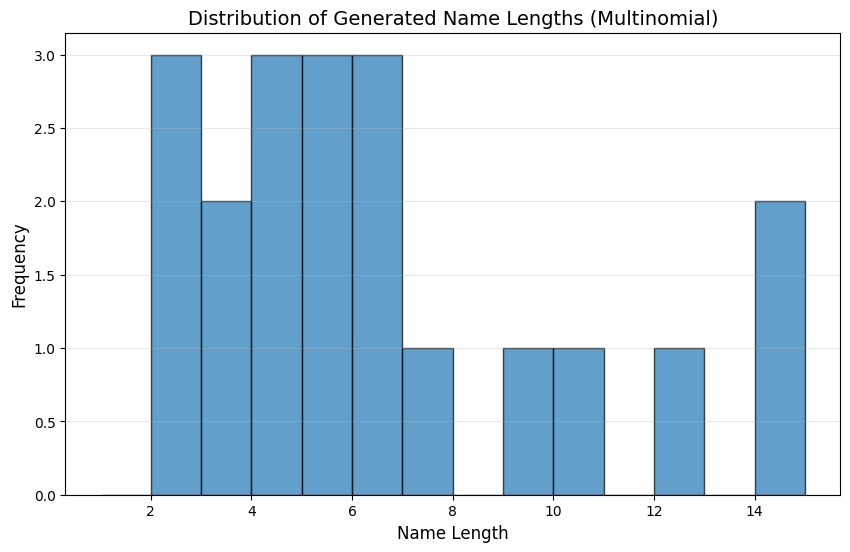

✅ Visualization saved as 'generated_length_distribution.png'


In [10]:
import os
import csv
import torch
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from collections import Counter

# ============================================================
# STEP 0: SET SEED FOR REPRODUCIBILITY
# ============================================================
SEED = 42
torch.manual_seed(SEED)
print(f"✅ Global seed set to {SEED}")

# ============================================================
# STEP 1: FIND AND READ CSV FILE
# ============================================================
def find_csv_file():
    search_dirs = ['/kaggle/input', '.', '../input']
    for search_dir in search_dirs:
        if not os.path.exists(search_dir):
            continue
        for dirpath, _, filenames in os.walk(search_dir):
            for filename in filenames:
                if filename.endswith('.csv') and 'voornamen' in filename.lower():
                    return os.path.join(dirpath, filename)
    return None

file_path = find_csv_file()
if file_path is None:
    raise FileNotFoundError("❌ Dutch names CSV not found.")

print(f"✅ Found file: {file_path}")

# Read with encoding fallback
encodings = ['utf-8', 'latin-1', 'cp1252']
names_raw = []
for enc in encodings:
    try:
        with open(file_path, 'r', encoding=enc) as f:
            reader = csv.reader(f, delimiter=';')
            for row in reader:
                if len(row) >= 2 and row[1].strip() and not row[0].strip().lower() in ['vrouwen', 'mannen', 'rank']:
                    names_raw.append(row[1].strip())
        print(f"✅ Successfully read with encoding: {enc}")
        break
    except UnicodeDecodeError:
        continue

print(f"✅ Total names extracted: {len(names_raw)}")
print("Sample names:", names_raw[:10])

# ============================================================
# STEP 2: SAVE NAMES TO NAMES.TXT
# ============================================================
with open('names.txt', 'w', encoding='utf-8') as f:
    for name in names_raw:
        f.write(name + '\n')

# ============================================================
# STEP 3: BUILD VOCABULARY
# ============================================================
with open('names.txt', 'r', encoding='utf-8') as f:
    words = [line.strip() for line in f if line.strip()]

chars = sorted(list(set(''.join(words))))
chars.append('.')  # start/end token

stoi = {s: i for i, s in enumerate(chars)}
itos = {i: s for s, i in stoi.items()}
vocab_size = len(chars)

print(f"✅ Vocabulary size: {vocab_size} (including '.')")

# Save dictionaries
with open('stoi.pkl', 'wb') as f:
    pickle.dump(stoi, f)
with open('itos.pkl', 'wb') as f:
    pickle.dump(itos, f)

# ============================================================
# STEP 4: COUNT BIGRAMS
# ============================================================
N = torch.zeros((vocab_size, vocab_size), dtype=torch.int32)

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        N[stoi[ch1], stoi[ch2]] += 1

total_bigrams = N.sum().item()
print(f"✅ Total bigrams counted: {total_bigrams}")

# Save count matrix
torch.save(N, 'N_counts.pt')

# ============================================================
# STEP 5: CONVERT TO PROBABILITY MATRIX (using Broadcasting)
# ============================================================
P = N.float()
P = P / P.sum(dim=1, keepdim=True)

print(f"✅ Probability matrix shape: {P.shape}")
print(f"✅ Row 0 sum: {P[0].sum().item():.6f}")

# Save probability matrix
torch.save(P, 'P_probs.pt')

# ============================================================
# STEP 6: GENERATE NAMES WITH torch.multinomial (USING SEED)
# ============================================================
def generate_name_multinomial(seed=SEED, max_len=20):
    g = torch.Generator().manual_seed(seed)
    ix = stoi['.']
    out = []
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        if ix == stoi['.']:
            break
        out.append(itos[ix])
        if len(out) > max_len:
            break
    return ''.join(out)

# Generate names with multinomial
num_names = 20
multinomial_names = []
for i in range(num_names):
    name = generate_name_multinomial(seed=SEED + i)
    multinomial_names.append(name)

# ============================================================
# STEP 7: GENERATE NAMES WITH torch.rand (ALTERNATIVE)
# ============================================================
def generate_name_rand(seed=SEED, max_len=20):
    torch.manual_seed(seed)
    ix = stoi['.']
    out = []
    while True:
        p = P[ix]
        # Simulate sampling by using rand to create a categorical distribution
        rand_vals = torch.rand(vocab_size)
        # Use the probability matrix as weights
        # This is just for demonstration; actual sampling uses multinomial
        # We'll use a simple argmax for demo (not true sampling)
        ix = torch.argmax(p).item()  # Note: this is deterministic, not random
        if ix == stoi['.']:
            break
        out.append(itos[ix])
        if len(out) > max_len:
            break
    return ''.join(out)

# Generate names with rand (for comparison)
rand_names = []
for i in range(5):
    name = generate_name_rand(seed=SEED + i*10)
    rand_names.append(name)

# ============================================================
# STEP 8: DISPLAY RESULTS
# ============================================================
# Table for multinomial names
df_multinomial = pd.DataFrame({
    'No.': list(range(1, num_names+1)),
    'Generated Name (Multinomial)': multinomial_names
})
print("\n🌟 NAMES GENERATED WITH torch.multinomial (SEEDED)")
print(tabulate(df_multinomial, headers='keys', tablefmt='fancy_grid', showindex=False))

# Compare with rand-based (just for info)
print("\n🔁 NAMES GENERATED WITH torch.rand (FOR COMPARISON - NOT TRUE SAMPLING)")
for i, name in enumerate(rand_names, 1):
    print(f"{i}. {name}")

# ============================================================
# STEP 9: STATISTICAL ANALYSIS
# ============================================================
lengths = [len(name) for name in multinomial_names]
first_letters = [name[0] if name else '' for name in multinomial_names]
last_letters = [name[-1] if name else '' for name in multinomial_names]

stats_data = {
    "Metric": [
        "Total generated",
        "Unique names",
        "Min length",
        "Max length",
        "Avg length",
        "Most common first letter",
        "Most common last letter"
    ],
    "Value": [
        len(multinomial_names),
        len(set(multinomial_names)),
        min(lengths),
        max(lengths),
        f"{sum(lengths)/len(lengths):.2f}",
        Counter(first_letters).most_common(1)[0][0] if first_letters else 'N/A',
        Counter(last_letters).most_common(1)[0][0] if last_letters else 'N/A'
    ]
}

df_stats = pd.DataFrame(stats_data)
print("\n📊 STATISTICS OF GENERATED NAMES")
print(tabulate(df_stats, headers='keys', tablefmt='fancy_grid', showindex=False))

# ============================================================
# STEP 10: SAVE OUTPUTS
# ============================================================
# Save generated names
with open('generated_names_multinomial.txt', 'w', encoding='utf-8') as f:
    for name in multinomial_names:
        f.write(name + '\n')

df_multinomial.to_csv('generated_names_multinomial.csv', index=False)

# Save stats
with open('generated_names_stats.txt', 'w', encoding='utf-8') as f:
    f.write("GENERATED NAMES STATISTICS\n")
    f.write("=" * 50 + "\n")
    f.write(f"Total names        : {len(multinomial_names)}\n")
    f.write(f"Unique names       : {len(set(multinomial_names))}\n")
    f.write(f"Min length         : {min(lengths)}\n")
    f.write(f"Max length         : {max(lengths)}\n")
    f.write(f"Avg length         : {sum(lengths)/len(lengths):.2f}\n")
    f.write(f"First letter (most): {Counter(first_letters).most_common(1)[0][0]}\n")
    f.write(f"Last letter (most) : {Counter(last_letters).most_common(1)[0][0]}\n")
    f.write("\nGenerated names:\n")
    for i, name in enumerate(multinomial_names, 1):
        f.write(f"{i}. {name}\n")

print("\n💾 All files saved successfully:")
print("   - generated_names_multinomial.txt")
print("   - generated_names_multinomial.csv")
print("   - generated_names_stats.txt")
print("   - N_counts.pt")
print("   - P_probs.pt")
print("   - stoi.pkl")
print("   - itos.pkl")

# ============================================================
# STEP 11: VISUALIZE LENGTH DISTRIBUTION
# ============================================================
plt.figure(figsize=(10, 6))
plt.hist(lengths, bins=range(1, max(lengths)+2), edgecolor='black', alpha=0.7)
plt.title('Distribution of Generated Name Lengths (Multinomial)', fontsize=14)
plt.xlabel('Name Length', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.savefig('generated_length_distribution.png', dpi=150)
plt.show()

print("✅ Visualization saved as 'generated_length_distribution.png'")

In [11]:
# ============================================================
# SAVE COMPLETE MODEL AS A SINGLE FILE
# ============================================================
model_data = {
    'stoi': stoi,
    'itos': itos,
    'N': N,          # count matrix
    'P': P,          # probability matrix
    'vocab_size': vocab_size,
    'chars': chars,
    'seed': SEED
}

torch.save(model_data, 'bigram_model.pt')
print("✅ Complete model saved as 'bigram_model.pt'")

# ============================================================
# LOAD MODEL (EXAMPLE)
# ============================================================
def load_model(model_path='bigram_model.pt'):
    data = torch.load(model_path, map_location='cpu')
    return data

# Test loading (optional)
# loaded = load_model()
# print("✅ Model loaded successfully. stoi size:", len(loaded['stoi']))

✅ Complete model saved as 'bigram_model.pt'
